# Рабочая тетрадь по ПСИИ №3

## БФБО-06-24 Петров Артем

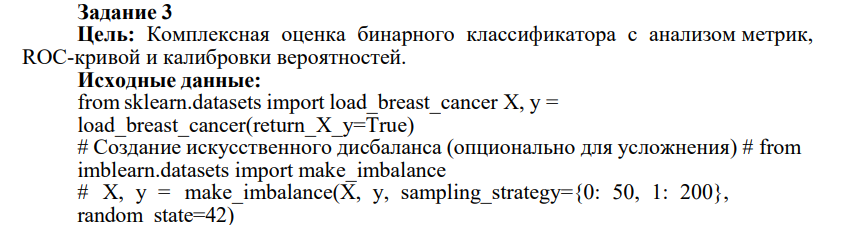

In [1]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y = True)
# Создание искусственного дисбаланса (опционально для усложнения)
from imblearn.datasets import make_imbalance
# X, y = make_imbalance(X, y, sampling_strategy = {0: 50, 1: 200}, random_state = 42)

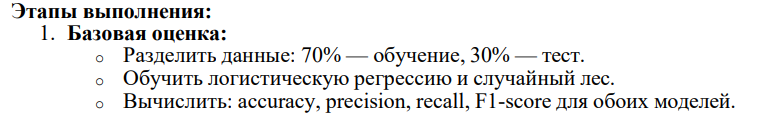

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Разделение данных на выборки:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Объявление и обучение моделей:
log_reg = LogisticRegression(max_iter = 10000, random_state = 42)
log_reg.fit(X_train, y_train)

rand_forest = RandomForestClassifier(n_estimators = 100, random_state = 42)
rand_forest.fit(X_train, y_train)

# Создание предсказаний:
log_reg_pred = log_reg.predict(X_test)
rand_forest_pred = rand_forest.predict(X_test)

# Для удобства создадим ф-цию для вывода метрик:
def print_metrics(y_true, y_pred, model_name):
    print(f"\n\t{model_name}:")
    print(f'Accuracy: {accuracy_score(y_true, y_pred)};')
    print(f'Precision: {accuracy_score(y_true, y_pred)};')
    print(f'Recall: {recall_score(y_true, y_pred)};')
    print(f'F1-score: {f1_score(y_true, y_pred)}.')

# Вывод метрик для оценки точности моделей:
print_metrics(y_test, log_reg_pred, "Logistic Regression")
print_metrics(y_test, rand_forest_pred, "Random Forest")


	Logistic Regression:
Accuracy: 1.0;
Precision: 1.0;
Recall: 1.0;
F1-score: 1.0.

	Random Forest:
Accuracy: 0.9866666666666667;
Precision: 0.9866666666666667;
Recall: 0.9838709677419355;
F1-score: 0.991869918699187.


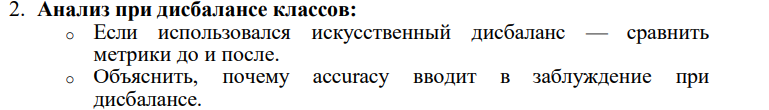

In [7]:
# Теперь обучим модели на датасете с использованием искусственного дисбаланса:
X1, y1 = make_imbalance(X, y, sampling_strategy = {0: 50, 1: 200}, random_state = 42)

# Разделим разбалансированных датасет на тестовые и обучающие выборки:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.3, random_state = 42)

# Теперь зададим и обучим модели на новых данных:
lr_imb = LogisticRegression(max_iter = 10000, random_state = 42)
lr_imb.fit(X1_train, y1_train)

rf_imb = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_imb.fit(X1_train, y1_train)

# Далее создадим предсказания и сделаем вывод метрик при помощи ф-ции описанной ранее:
lr_imb_pred = lr_imb.predict(X1_test)
rf_imb_pred = rf_imb.predict(X1_test)

print_metrics(y1_test, lr_imb_pred, "Logistic Regression + disbalance")
print_metrics(y1_test, rf_imb_pred, "Random Forest + disbalance")


	Logistic Regression + disbalance:
Accuracy: 0.9866666666666667;
Precision: 0.9866666666666667;
Recall: 0.9838709677419355;
F1-score: 0.991869918699187.

	Random Forest + disbalance:
Accuracy: 0.9733333333333334;
Precision: 0.9733333333333334;
Recall: 0.967741935483871;
F1-score: 0.9836065573770492.


## Почему Accuracy вводит в заблуждение при дисбалансе?

Высокое значение Accuracy может замаскировать неспособность модели находить нужных класс. К примеру, в случае когда 95 объектов будут '0' класса и 5 '1'-го и модель предсказывает все объекты как класс '0' - Accuracy будет равняться 95/100, что является замечательным результатом, но при этом recall для '1'-го класса будет равен 0/5, что в свою очередь является очень плохим результатом, который раскрывает недостаток модели. Таким образом, при дисбалансе, метрики recall и precision более честно отражают качество модели.

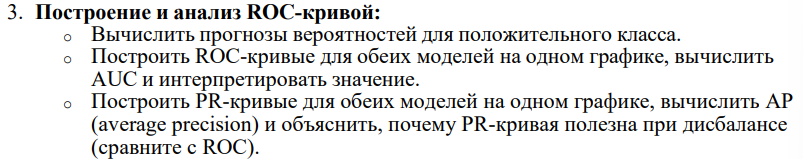

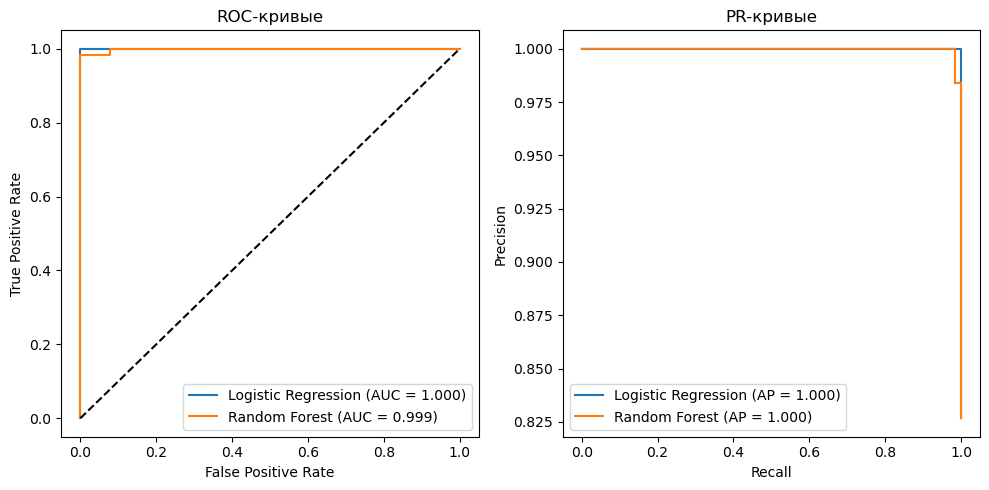

In [9]:
# Вероятности для ROC
log_reg_prob = log_reg.predict_proba(X_test)[:, 1]
rand_forest_prob = rand_forest.predict_proba(X_test)[:, 1]

# ROC-кривая, объявление переменных и визуализация:
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, log_reg_prob)
fpr_rand_forest, tpr_rand_forest, _ = roc_curve(y_test, rand_forest_prob)

roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)
roc_auc_rand_forest = auc(fpr_rand_forest, tpr_rand_forest)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_log_reg, tpr_log_reg, label = f'Logistic Regression (AUC = {roc_auc_log_reg:.3f})')
plt.plot(fpr_rand_forest, tpr_rand_forest, label = f'Random Forest (AUC = {roc_auc_rand_forest:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()

# PR-кривя, объявление переменных и визуализация:
precision_log_reg, recall_log_reg, _ = precision_recall_curve(y_test, log_reg_prob)
precision_rand_forest, recall_rand_forest, _ = precision_recall_curve(y_test, rand_forest_prob)

ap_log_reg = average_precision_score(y_test, log_reg_prob)
ap_rand_forest = average_precision_score(y_test, rand_forest_prob)

plt.subplot(1, 2, 2)
plt.plot(recall_log_reg, precision_log_reg, label = f'Logistic Regression (AP = {ap_log_reg:.3f})')
plt.plot(recall_rand_forest, precision_rand_forest, label = f'Random Forest (AP = {ap_rand_forest:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривые')
plt.legend()
plt.tight_layout()
plt.show()

## Почему PR-кривая полезна при дисбалансе в сравнении с ROC?

ROC-кривая показывает способность модели ранжировать объекты, но при сильном дисбалансе может создавать ложное впечатление хорошей работы модели из-за большого количества True Negatives. PR-кривая фокусируется на положительном классе и показывает реальную практическую ценность модели, особенно когда положительный класс редкий, но важный. Так же, Average Precision лучше отражает качество модели при дисбалансе, так как усредняет precision по разным уровням recall.

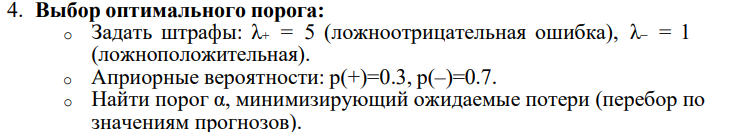

In [17]:
# Для начал объявим переменные:
# Штрафы за ошибки:
lambda_plus = 5 # FN
lambda_minus = 1 # FP

# Априорные вероятности:
p_plus = 0.3
p_minus = 0.7

# объявляем вероятности для одной модели, выберем случайны лес.
# ранее уже была объявлена переменная содержащая их - "log_reg_prob"

# Переберём пороги:
thresholds = np.linspace(0, 1, 100)
best_treshold = 0
min_loss = np.inf

for thresh in thresholds:
    rand_forest_pred_custom = (rand_forest_prob >= thresh).astype(int)

    tn = np.sum((y_test == 0) & (rand_forest_pred_custom == 0))
    fp = np.sum((y_test == 0) & (rand_forest_pred_custom == 1))
    fn = np.sum((y_test == 1) & (rand_forest_pred_custom == 0))
    tp = np.sum((y_test == 1) & (rand_forest_pred_custom == 1))

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 1

    loss = lambda_plus * p_plus * (1 - recall) + lambda_minus * p_minus * fpr

    if loss < min_loss:
        min_loss = loss
        best_threshold = thresh

print(f'Оптимальный порог: \n{best_threshold};\nМинимальные потери:\n{min_loss}.')

Оптимальный порог: 
0.4141414141414142;
Минимальные потери:
0.024193548387096753.


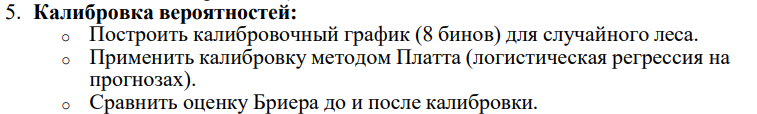

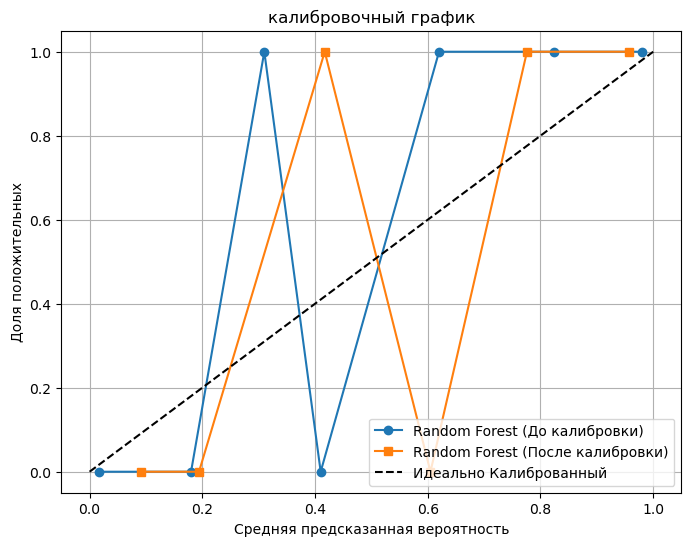

Brier score до калибровки: 0.013267999999999999;
Brier score после калибровки: 0.013871763008317594;


In [20]:
# Калибровка случайного леса:
rf_calibrated = CalibratedClassifierCV(rand_forest, method = 'sigmoid', cv = 5)
rf_calibrated.fit(X_train, y_train)
probs_rf_calib = rf_calibrated.predict_proba(X_test)[:, 1]

# Объявление переменных и калибровочный график
prob_true, prob_pred = calibration_curve(y_test, rand_forest_prob, n_bins = 8)
prob_true_calib, prob_pred_calib = calibration_curve(y_test, probs_rf_calib, n_bins = 8)

plt.figure(figsize = (8,6))
plt.plot(prob_pred, prob_true, marker = 'o', label = 'Random Forest (До калибровки)')
plt.plot(prob_pred_calib, prob_true_calib, marker = 's', label = 'Random Forest (После калибровки)')
plt.plot([0, 1], [0, 1], 'k--', label = 'Идеально Калиброванный')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных')
plt.title('калибровочный график')
plt.legend()
plt.grid()
plt.show()

# оценка Бриера:
brier_before = brier_score_loss(y_test, rand_forest_prob)
brier_after = brier_score_loss(y_test, probs_rf_calib)
print(f'Brier score до калибровки: {brier_before};\nBrier score после калибровки: {brier_after};')

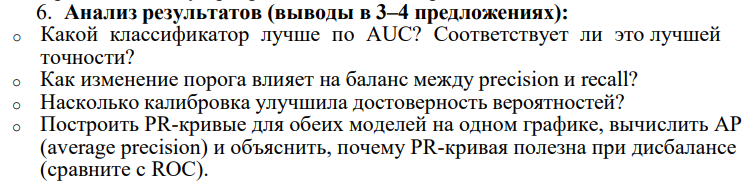

## Какой классификатор лучше по AUC? Соответствует ли это лучшей точности?

По AUC лучше Логистическая регрессия

## Как изменение порога влияет на баланс между precision и recall?

## Насколько калибровка улучшила достоверность вероятностей?

## Почему PR-кривая полезна при дисбалансе в сравнении с ROC?

Ответ был описан ранее, после задания 3.